# Project Objective

Develop a predictive model that estimates the **median home values** in Boston suburbs using socio-economic and environmental factors, while exploring the key variables that influence housing prices.

I use the following dataset: https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset


I will to perform data cleaning, exploratory data analysis (EDA), feature selection, and build regression models to understand which features influence housing prices.

## Variable Descriptions

1. **crim**: Per capita crime rate by town.
2. **zn**: Proportion of residential land zoned for lots over 25,000 square feet.
3. **indus**: Proportion of non-retail business acres per town.
4. **chas**: Charles River dummy variable (1 if tract bounds river; 0 otherwise).
5. **nox**: Nitric oxide concentration (parts per 10 million).
6. **rm**: Average number of rooms per dwelling.
7. **age**: Proportion of owner-occupied units built prior to 1940.
8. **dis**: Weighted distances to five Boston employment centers.
9. **rad**: Index of accessibility to radial highways.
10. **tax**: Full-value property tax rate per 10,000 dollars.
11. **ptratio**: Pupil-teacher ratio by town.
12. **b**: 1000(Bk - 0.63)^2, where Bk is the proportion of Black residents by town.
13. **lstat**: Percentage of lower status population.
14. **medv**: Median value of owner-occupied homes in thousands of dollars.



In [1]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.model_selection import cross_val_score

In [2]:
path = "BostonHousing.csv"
df = pd.read_csv(path)
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


We have 506 elements in the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Found five elements in the column "rm" with missing values, we gotta remove this rows.

In [6]:
df.dropna(inplace = True)

In [7]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

After that process, we can confirm that our dataset has been cleaned and is ready to use.

## EDA

I wanna see what's the correlation betwen all variables in the dataset.

<Axes: >

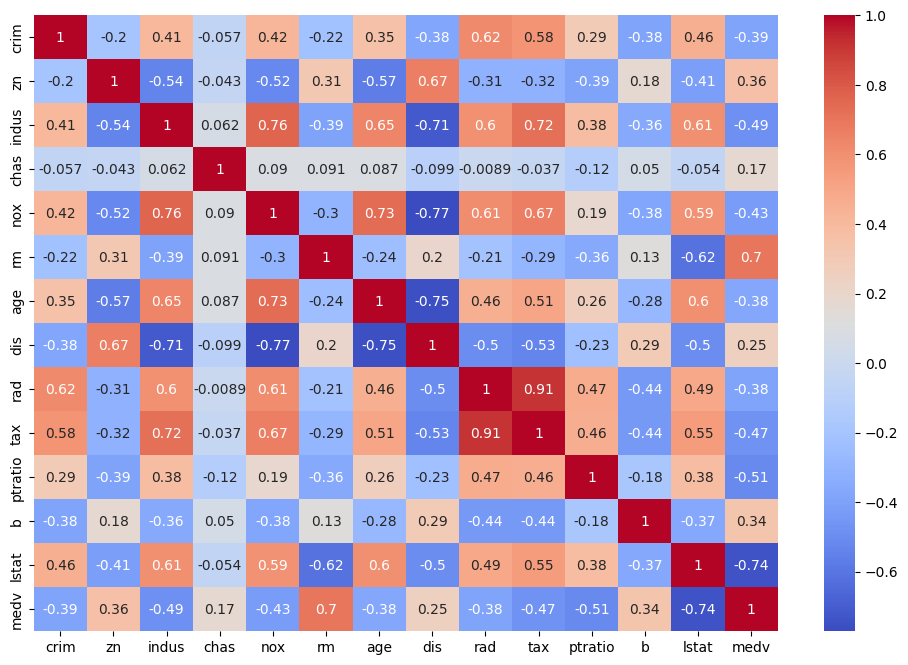

In [9]:
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), cbar = True, annot = True, cmap = "coolwarm")

### BoxPlot

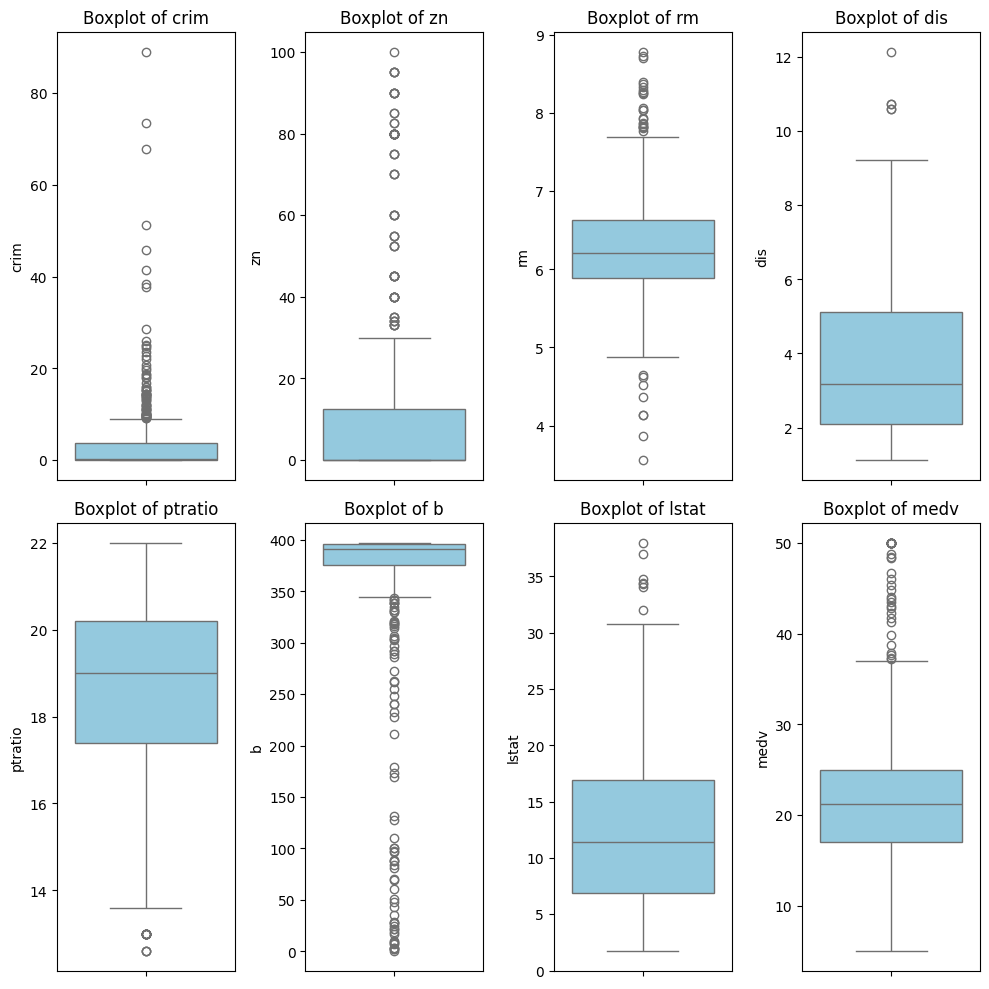

In [10]:
outlier_cols =['crim', 'zn', 'rm', 'dis', 'ptratio', 'b', 'lstat', 'medv']
n_cols = 4
n_rows = np.ceil(len(outlier_cols) / n_cols).astype(int)
plt.figure(figsize=(10, 5 * n_rows))
for i, col in enumerate(outlier_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col], color = "skyblue")
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Target Distribution

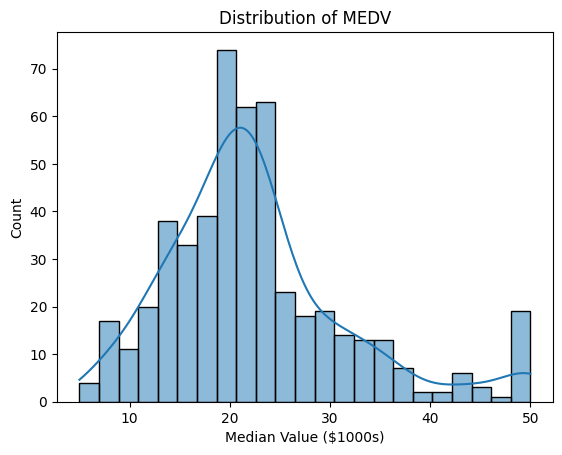

In [11]:
sns.histplot(df['medv'], kde=True)
plt.title("Distribution of MEDV")
plt.xlabel("Median Value ($1000s)")
plt.show()

### Correlation with Target

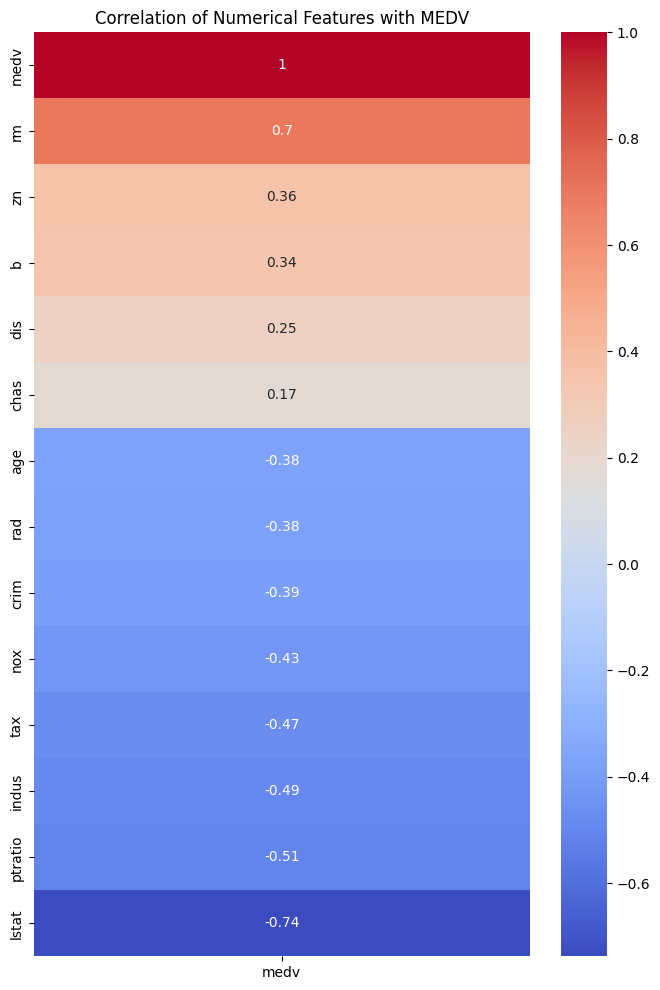

In [12]:
corr_mtx = df.corr(numeric_only=True)
medv_corr = corr_mtx[['medv']].sort_values(by='medv', ascending=False)
plt.figure(figsize=(8, 12))
sns.heatmap(medv_corr, annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Features with MEDV')
plt.show()

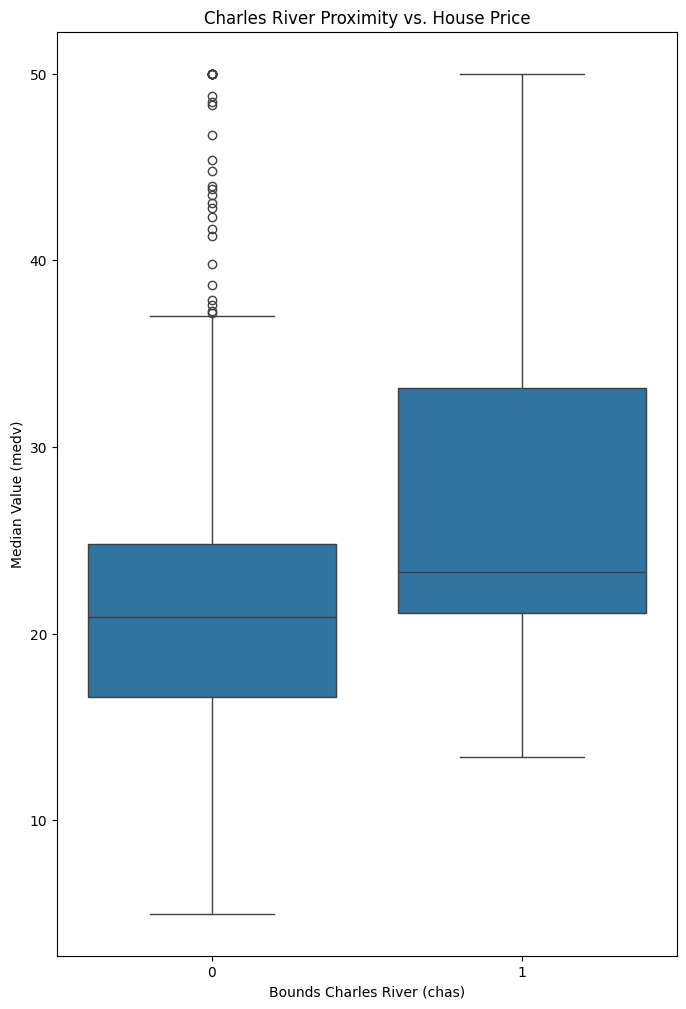

In [13]:
plt.figure(figsize=(8, 12))
sns.boxplot(data=df, x='chas', y='medv')
plt.title('Charles River Proximity vs. House Price')
plt.xlabel('Bounds Charles River (chas)')
plt.ylabel('Median Value (medv)')
plt.show()

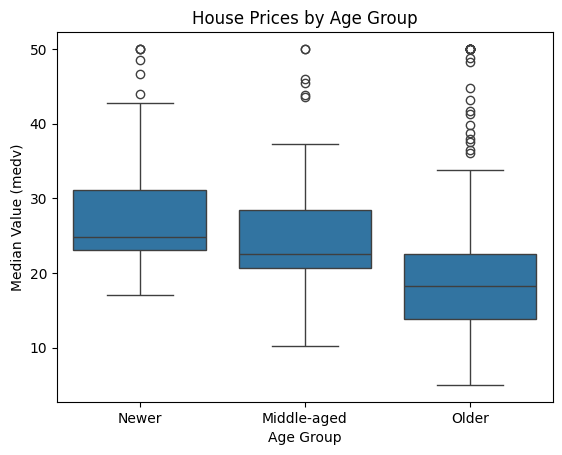

In [14]:
df['age_group'] = pd.cut(df['age'], bins=[0, 35, 70, 100], labels=['Newer', 'Middle-aged', 'Older'])

sns.boxplot(data=df, x='age_group', y='medv')
plt.title('House Prices by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Value (medv)')
plt.show()

### Scatterplots

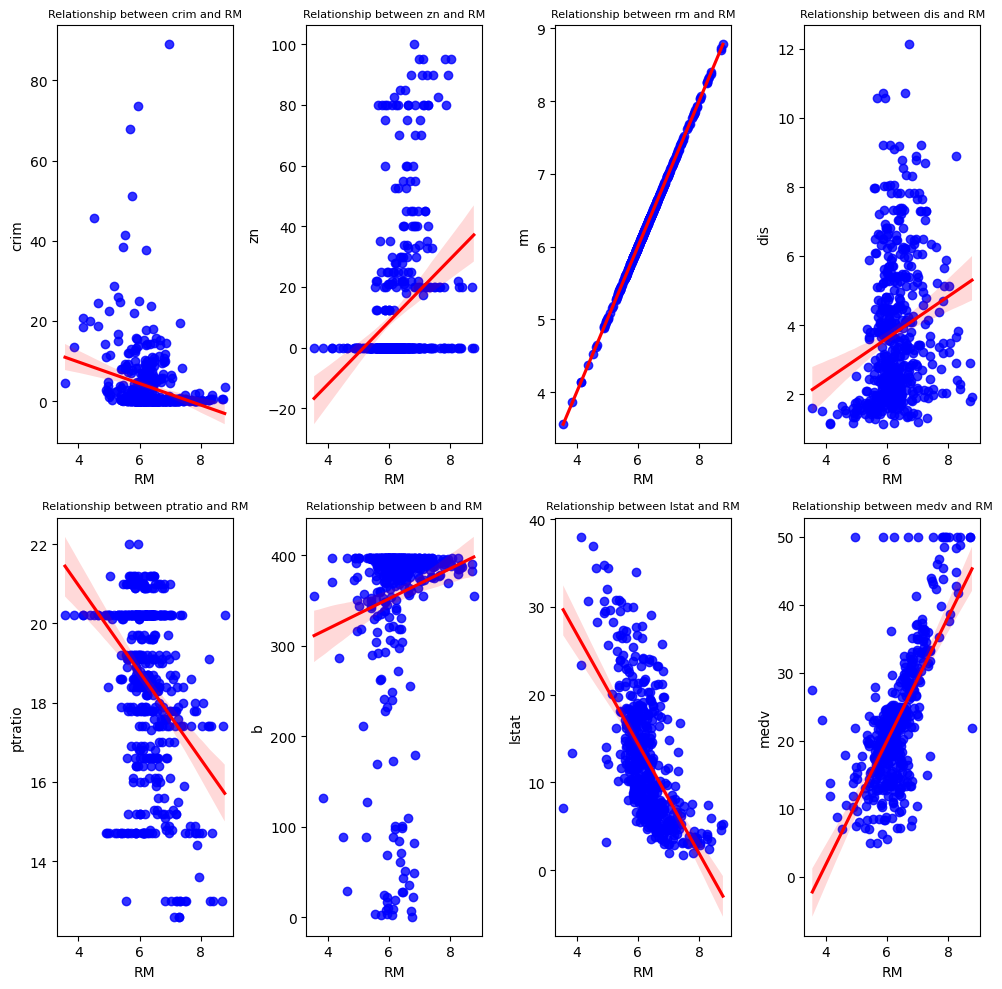

In [15]:

outlier_cols =['crim', 'zn', 'rm', 'dis', 'ptratio', 'b', 'lstat', 'medv']
n_cols = 4
n_rows = np.ceil(len(outlier_cols) / n_cols).astype(int)
plt.figure(figsize=(10, 5 * n_rows))
for i, col in enumerate(outlier_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.regplot(data=df, x='rm', y=col, scatter_kws={'color': 'blue'}, line_kws={"color": "red"})
    plt.title(f"Relationship between {col} and RM", fontsize=8)
    plt.ylabel(col)
    plt.xlabel('RM')

plt.tight_layout()
plt.show()

## Data Preprocessing

### Handle Outliers

In [16]:
def outliers_detect(df):
    rows = len(df)
    info =  {}

    for j in df.columns: #when j represent each row
        if j == 'age_group':
            continue
        Q1 = df[j].quantile(0.25)
        Q3 = df[j].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[j] < lower) | (df[j] > upper)]
        count = len(outliers)
        percent = (count / rows) * 100

        info[j] = {'count': count, 'percent': percent}

    return info

In [17]:
outliers = outliers_detect(df)

for col, info in outliers.items():
    print(f"{col}: {info['count']} rows ({info['percent']:.2f}%)")

crim: 66 rows (13.17%)
zn: 68 rows (13.57%)
indus: 0 rows (0.00%)
chas: 35 rows (6.99%)
nox: 0 rows (0.00%)
rm: 30 rows (5.99%)
age: 0 rows (0.00%)
dis: 5 rows (1.00%)
rad: 0 rows (0.00%)
tax: 0 rows (0.00%)
ptratio: 15 rows (2.99%)
b: 76 rows (15.17%)
lstat: 7 rows (1.40%)
medv: 37 rows (7.39%)


In [18]:
for col in df.columns:
    if col == 'age_group':
            continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

In [19]:
outliers = outliers_detect(df)

for col, info in outliers.items():
    print(f"{col}: {info['count']} rows ({info['percent']:.2f}%)")

crim: 0 rows (0.00%)
zn: 0 rows (0.00%)
indus: 0 rows (0.00%)
chas: 0 rows (0.00%)
nox: 0 rows (0.00%)
rm: 0 rows (0.00%)
age: 0 rows (0.00%)
dis: 0 rows (0.00%)
rad: 0 rows (0.00%)
tax: 0 rows (0.00%)
ptratio: 0 rows (0.00%)
b: 0 rows (0.00%)
lstat: 0 rows (0.00%)
medv: 0 rows (0.00%)


## Models

### Regression

In [20]:
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

X = df.drop('medv', axis=1) #splitting the target 
y = df['medv']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred= model.predict(X_test)

In [25]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.7624
MAE: 2.77
MSE: 13.81
RMSE: 3.72


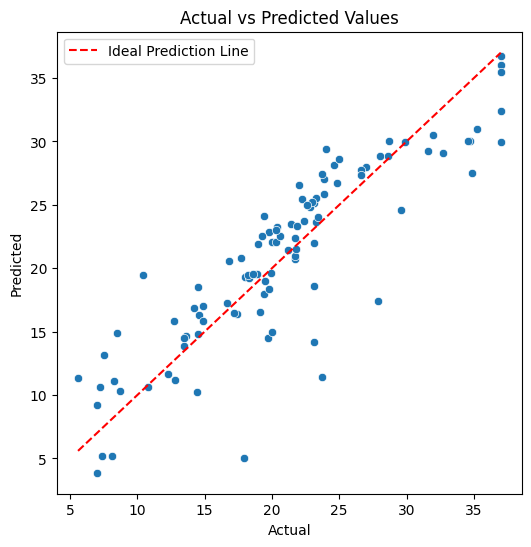

In [26]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Ideal Prediction Line')
plt.legend()
plt.show()